In [1]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a, b를 더한다"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a, b를 곱한다"""
    return a * b

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

## [Tool integrations](https://docs.langchain.com/oss/python/integrations/tools)

### Search

- [DuckDuckGo](https://docs.langchain.com/oss/python/integrations/tools/ddg)

In [3]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

search.invoke("Obama's first name?")

"The White House, official residence of the president of the United States The president of the United States is the head of state and head of government of the United States, [1] indirectly elected to a four-year term via the Electoral College. [2] Under the U.S. Constitution, the officeholder leads the executive branch of the federal government and is the commander-in-chief of the United ... Barack Obama, the 44th President of the United States, is no exception. While his name is widely recognized today, there's a fascinating story behind it, including questions about whether he ever changed his name or used a different one before rising to prominence. Understanding the origins of Barack Obama's name sheds light on his multicultural background and the diverse influences that ... Barack Obama, the 44th President of the United States, broke barriers as the first African-American president and implemented significant healthcare reforms during his tenure. Uncovering presidents' middle na

In [4]:
%pip install -q ddgs

Note: you may need to restart the kernel to use updated packages.


In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

### Productivity

- [Gmail toolkit](https://docs.langchain.com/oss/python/integrations/tools/google_gmail)

In [5]:
%pip install -qU langchain-google-community\[gmail\]

Note: you may need to restart the kernel to use updated packages.


In [5]:
from langchain_google_community import GmailToolkit
 
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/google_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

/Users/leehk/.pyenv/versions/tutorial-langchain/lib/python3.13/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/var/folders/fy/ttjmh_nn6qb8ndt1cywmbcqm0000gn/T/ipykernel_85171/1417800459.py:10: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/fy/ttjmh_nn6qb8ndt1cywmbcqm0000gn/T/ipykernel_85171/1417800459.py:15: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [19]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x120dd5590>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x120dd5590>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x120dd5590>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x120dd5590>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x120dd5590>)]

### ETC

- [ArXiv](https://docs.langchain.com/oss/python/integrations/tools/arxiv)
: 각종 논문이 모여 있는 사이트(https://arxiv.org/)에서 논문을 가져올 수 있는 API

In [9]:
%pip install -qU langchain-community arxiv

Note: you may need to restart the kernel to use updated packages.


In [6]:
"""패키지 변경됨"""
#from langchain.agents import load_tools
from langchain_community.agent_toolkits.load_tools import load_tools

arxiv_tools = load_tools(
    ["arxiv"],
)

In [21]:
arxiv_tools

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=3, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=4000))]

### Retriever Tool

- [create_retriever_tool](https://reference.langchain.com/python/langchain-core/tools/retriever/create_retriever_tool)
: [3.7.parallel-agent](../Ch03-LangGraph/3.7.parallel-agent.ipynb) 복잡한 Retriever를 간단하게 구현하게 해주는 Tool

In [7]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='estate_tax_collection',
    persist_directory='../Ch03-LangGraph/estate_tax'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='estate_tax_retriever',
    description='Contains information about korea estate tax retriever'
)

## Tool list

In [8]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list + arxiv_tools

llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [10]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [10]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [12]:
"""NODE 추가"""
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [13]:
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    tools_condition
)
graph_builder.add_edge('tools', 'agent')

## 채팅 히스토리

- 히스토리 관리를 위해서는 [checkpointer](https://docs.langchain.com/oss/python/langgraph/persistence#checkpointer-libraries)를 사용
- checkpointer는 아래 두가지 방법을 제공
  - 메모리에 저장
  - DB에 저장

In [14]:
from langgraph.checkpoint.memory import MemorySaver

"""
채팅 히스토리
"""
checkpointer = MemorySaver()

graph = graph_builder.compile(
    checkpointer = checkpointer
)

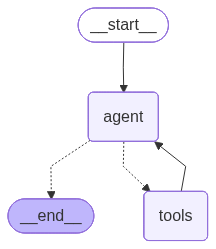

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
from langchain_core.messages import HumanMessage

"""
채팅 히스토리를 위한 Thread 관리
"""
config = {
    'configurable': {
        'thread_id': 'ActionsOverWords'
    }
}

query = 'https://arxiv.org/abs/1706.03762 논문을 요약해서 ActionsOverWords@gmail.com에게 보낼 이메일 초안을 작성해주세요.'
for chunk in graph.stream({
    'messages': [HumanMessage(query)]},
    config=config,
    stream_mode='values'
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

https://arxiv.org/abs/1706.03762 논문을 요약해서 ActionsOverWords@gmail.com에게 보낼 이메일 초안을 작성해주세요.
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_Vnxl8PggRsU8NEeukKgyIYou)
 Call ID: call_Vnxl8PggRsU8NEeukKgyIYou
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanism

In [16]:
query = '본문 내용을 보강해서 한글로 초안 작성해줘.'
for chunk in graph.stream({
    'messages': [HumanMessage(query)]},
    config=config,
    stream_mode='values'
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

본문 내용을 보강해서 한글로 초안 작성해줘.
================================== Ai Message ==================================
Tool Calls:
  create_gmail_draft (call_6xT7u2B0FpSMWLpqBKmzDPLv)
 Call ID: call_6xT7u2B0FpSMWLpqBKmzDPLv
  Args:
    message: 안녕하세요,

아래는 아쉬쉬 바스와니(Ashish Vaswani) 외 여러 저자의 논문 "Attention Is All You Need"에 대한 요약입니다.

1. **Transformer 모델 소개**: 이 논문에서는 Transformer라는 새로운 네트워크 아키텍처를 소개합니다. 이 아키텍처는 주의(attention) 메커니즘에 전적으로 의존하며, 반복(recurrence)과 합성곱(convolutions)을 완전히 배제합니다.

2. **전통적인 모델 대비 장점**: Transformer 모델은 기존의 복잡한 순환 또는 합성곱 신경망 기반의 모델에 비해 더 병렬화가 가능하며 훈련 시간이 상당히 단축됩니다.

3. **성능**: 기계 번역 작업에서의 실험 결과, Transformer는 이전의 최고 성능 모델을 능가하는 것으로 나타났습니다. WMT 2014 영어-독일어 번역 작업에서 Transformer는 28.4 BLEU 점수를 기록하여 기존의 최고 실적을 2 BLEU 점수 이상 능가하였습니다. 영어-프랑스어 번역 작업에서는 41.8의 새로운 단일 모델 최고 BLEU 점수를 기록했으며, 8개의 GPU를 사용하여 3.5일 만에 훈련을 완료하였습니다.

4. **일반화 능력**: Transformer 모델은 기계 번역뿐만 아니라 영어 구성 구문 분석에서도 성공적이었으며, 대규모 및 제한된 훈련 데이터셋 모두에

## 채팅 히스토리

- 위와같이 작성할 경우 `agent`에서 이전 대화가 계속 누적되어 관리됨
  > 메시지를 정리할 필요가 있음

In [11]:
def agent(state: MessagesState):
    messages = state['messages']
    print(f'message len == {len(messages)}')
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [15]:
from langchain_core.messages import HumanMessage

"""
채팅 히스토리를 위한 Thread 관리
"""
config = {
    'configurable': {
        'thread_id': 'ActionsOverWords'
    }
}

query = 'https://arxiv.org/abs/1706.03762 논문을 요약해서 ActionsOverWords@gmail.com에게 보낼 이메일 초안을 작성해주세요.'
for chunk in graph.stream({
    'messages': [HumanMessage(query)]},
    config=config,
    stream_mode='values'
):
    pass

message len == 1
message len == 3
message len == 5


In [64]:
query = '본문 내용을 보강해서 한글로 초안 작성해줘.'
for chunk in graph.stream({
    'messages': [HumanMessage(query)]},
    config=config,
    stream_mode='values'
):
    pass

message len == 7
message len == 9


### 수동으로 메시지 삭제

- LangChain에서 지원
- [RemoveMessage](https://docs.langchain.com/oss/python/langchain/short-term-memory#delete-messages)

In [17]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[HumanMessage(content='https://arxiv.org/abs/1706.03762 논문을 요약해서 이메일 초안을 작성해주세요.', additional_kwargs={}, response_metadata={}, id='e2e8a19a-6613-4925-9241-2b8f5470fe76'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 763, 'total_tokens': 781, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb58b86ca5', 'id': 'chatcmpl-Dg3GrOr2wDOOrA84bxvv7PYshTFd9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2f94-7c0e-7e71-9a69-8ee831cc008b-0', tool_calls=[{'name': 'arxiv', 'args': {'query': '1706.03762'}, 'id': 'call_I5a5PWbsCFZ2WhaPmJN1QRkK', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 

AIMessage(content='한글로 강화된 논문 요약 내용을 포함해서 초안을 작성했습니다. 제목은 "논문 요약: Attention Is All You Need"이며, 수신인은 "example@example.com"입니다. 이메일 초안을 확인해 보세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 1807, 'total_tokens': 1859, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1664}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c04e52b130', 'id': 'chatcmpl-DfiZMM06zgN98gviiEyl2hMu9h3DT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2ad6-3ea4-7fd1-8e69-74387f2ac923-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1807, 'output_tokens': 52, 'total_tokens': 1859, 'input_token_details': {'audio': 0, 'cache_read': 1664}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]

- current_message_list 에서 마지막 메시지인 AIMessage만 제외하고 나머지 9개 메시지를 삭제해본다.

In [18]:
from langchain_core.messages import RemoveMessage

for index, message in enumerate(current_message_list):
    if index < len(current_message_list) - 1:
        graph.update_state(config, {'messages': RemoveMessage(message.id)})

In [19]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='The email draft has been successfully created with the summary of the paper "Attention Is All You Need." If you need any more help, feel free to ask!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 1307, 'total_tokens': 1340, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb58b86ca5', 'id': 'chatcmpl-Dg3GujHsPMpyklo32C2JLueuqXjtH', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2f94-8a2d-71b2-8a90-f433354f0349-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1307, 'output_tokens': 33, 'total_tokens': 1340, 'input_token_details': {'audio': 0, 'cache_read': 1280}, 'output_token_details': {'a

## LangGraph.`Node`로 삭제

In [20]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: MessagesState):
    messages = state['messages']
    """
    마지막 3개의 메시지를 제외한 나머지 메시지를 삭제
    """
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [21]:
def should_continue(state: MessagesState):
    messages = state['messages']
    last_message = messages[-1]
    
    if last_message.tool_calls:
        return 'tools'
    return 'delete_messages'

In [22]:
#graph_builder.add_node('delete_messages', delete_messages
"""
node 이름과 함수 이름이 같으면 아래와 같이 축약 가능
"""
graph_builder.add_node(delete_messages)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [23]:
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', 'delete_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('delete_messages', END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [24]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph = graph_builder.compile(
    checkpointer = checkpointer
)

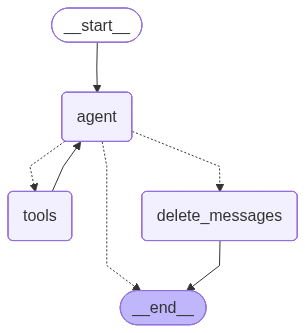

In [25]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'ActionsOverWords'
    }
}

query = 'https://arxiv.org/abs/1706.03762 논문을 요약해서 ActionsOverWords@gmail.com에게 보낼 이메일 초안을 작성해주세요.'
for chunk in graph.stream({
    'messages': [HumanMessage(query)]},
    config=config,
    stream_mode='values'
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

https://arxiv.org/abs/1706.03762 논문을 요약해서 ActionsOverWords@gmail.com에게 보낼 이메일 초안을 작성해주세요.
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_Qp0tyA8MAceEJWMB7rXh01ii)
 Call ID: call_Qp0tyA8MAceEJWMB7rXh01ii
  Args:
    query: https://arxiv.org/abs/1706.03762
================================= Tool Message =================================
Name: arxiv

No good Arxiv Result was found
================================== Ai Message ==================================

The paper with the identifier "1706.03762" seems to be unavailable on ArXiv at the moment. However, if you have access to this document by another means, feel free to provide the text or key points you wish to include in the email.
================================== Ai Message ==================================

The paper with the identifier "1706.03762" seems to be unavailable on ArXiv at the

## 강좌 오류

- 강좌에서는 `MessagesState`를 사용해서 node를 정의했지만 AgentState Class를 사용해야 함
  - 요약을 위해 AgentState로 변경
- 참고: https://github.com/jasonkang14/inflearn-langgraph-agent/blob/main/3.5%20Agent%EC%9D%98%20%ED%9E%88%EC%8A%A4%ED%86%A0%EB%A6%AC%EB%A5%BC%20%EA%B4%80%EB%A6%AC%ED%95%98%EB%8A%94%20%EB%B0%A9%EB%B2%95.ipynb

```python
class AgentState(MessagesState):
    summary: str
```

In [9]:
from langgraph.graph import MessagesState

class AgentState(MessagesState):
    summary: str

In [10]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState) -> AgentState:
    messages = state['messages']
    print(f'message len == {len(messages)}')

    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages

    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [11]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState) -> AgentState:
    messages = state['messages']
    """
    마지막 3개의 메시지를 제외한 나머지 메시지를 삭제
    """
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [12]:
def summarize_messages(state: AgentState) -> AgentState:
    messages = state['messages']
    summary = state['summary']

    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'

    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
chat_history:{messages}
summary:{summary}'''

    summary = llm.invoke(summary_prompt)
    return {'summary': summary.content}

In [13]:
def should_continue(state: AgentState) -> AgentState:
    messages = state['messages']
    last_message = messages[-1]
    
    if last_message.tool_calls:
        return 'tools'
    return 'summarize_messages'

In [14]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [15]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)

In [16]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

In [17]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph = graph_builder.compile(
    checkpointer = checkpointer
)

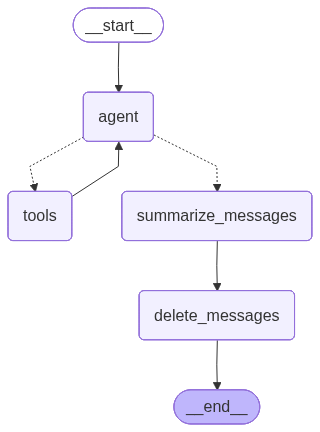

In [18]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'ActionsOverWords'
    }
}

query = 'https://arxiv.org/abs/1706.03762 논문을 요약해서 ActionsOverWords@gmail.com에게 보낼 이메일 초안을 작성해주세요.'
for chunk in graph.stream(
    {'messages': [HumanMessage(query)], 'summary': ''},
    config=config,
    stream_mode='values'
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

https://arxiv.org/abs/1706.03762 논문을 요약해서 ActionsOverWords@gmail.com에게 보낼 이메일 초안을 작성해주세요.
message len == 1
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_s31rT0fYGr9TUZrDFcUc5xHH)
 Call ID: call_s31rT0fYGr9TUZrDFcUc5xHH
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on at

In [20]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 314, 'prompt_tokens': 1079, 'total_tokens': 1393, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb58b86ca5', 'id': 'chatcmpl-Dg3QyQ8eqE3AUynx059KNyykyHGA0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2f9e-0d04-7710-936b-9bae0b513c60-0', tool_calls=[{'name': 'create_gmail_draft', 'args': {'message': 'Subject: Summary of \'Attention Is All You Need\' (1706.03762)\n\nDear ActionsOverWords,\n\nI hope this message finds you well. Below is a summary of the arXiv paper titled "Attention Is All You Need" by Ashish Vaswani et al.\n\nThe paper introduces a new, simplified neural network a

In [21]:
current_summary = graph.get_state(config).values['summary']
current_summary

'In the chat history provided, a human user requested the AI system to summarize the paper titled "Attention Is All You Need" (arXiv ID: 1706.03762) and draft an email with this summary to be sent to the email address ActionsOverWords@gmail.com. The AI system accessed the paper\'s details, including its publication information and a summary of its content, which highlights the introduction of the Transformer model. The Transformer model utilizes attention mechanisms, making it more efficient and superior in quality compared to traditional models using recurrent and convolutional neural networks. It achieves notable improvements in machine translation tasks, particularly in the WMT 2014 English-to-German and English-to-French translation tasks. \n\nThe AI then created an email draft containing the summary and confirmed its readiness for review and sending. The email was addressed to ActionsOverWords@gmail.com, and the user was informed that the draft is prepared.'

In [22]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'ActionsOverWords'
    }
}

query = '논문의 URL을 포함시켜주세요.'
for chunk in graph.stream(
    {'messages': [HumanMessage(query)], 'summary': ''},
    config=config,
    stream_mode='values'
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

논문의 URL을 포함시켜주세요.
message len == 4
================================== Ai Message ==================================
Tool Calls:
  search_gmail (call_ZmGemXqPxsrnp90tbSzB1h1P)
 Call ID: call_ZmGemXqPxsrnp90tbSzB1h1P
  Args:
    query: arxiv 1706.03762
    resource: messages
    max_results: 5
================================= Tool Message =================================
Name: search_gmail

[{"id": "19e2f9e1a70fba45", "threadId": "19e2f9e1a70fba45", "snippet": "Subject: Summary of &#39;Attention Is All You Need&#39; (1706.03762) Dear ActionsOverWords, I hope this message finds you well. Below is a summary of the arXiv paper titled &quot;Attention Is All You", "body": "Subject: Summary of 'Attention Is All You Need' (1706.03762)\n\nDear ActionsOverWords,\n\nI hope this message finds you well. Below is a summary of the arXiv paper titled \"Attention Is All You Need\" by Ashish Vaswani et al.\n\nThe paper in

In [23]:
graph.get_state(config).values['messages']

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 354, 'prompt_tokens': 2886, 'total_tokens': 3240, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb58b86ca5', 'id': 'chatcmpl-Dg3RNRYvPkSDEMJgudcb2zMfC6dDm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2f9e-6d61-73d3-ac0e-6cbd98500e89-0', tool_calls=[{'name': 'create_gmail_draft', 'args': {'message': 'Subject: Summary of \'Attention Is All You Need\' (1706.03762)\n\nDear ActionsOverWords,\n\nI hope this message finds you well. Below is a summary of the arXiv paper titled "Attention Is All You Need" by Ashish Vaswani et al.\n\nThe paper introduces a new, simplified neural networ

In [24]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'ActionsOverWords'
    }
}

query = '한글로 작성해주세요.'
for chunk in graph.stream(
    {'messages': [HumanMessage(query)], 'summary': ''},
    config=config,
    stream_mode='values'
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

한글로 작성해주세요.
message len == 4
================================== Ai Message ==================================

물론이죠. 이제 이메일 초안을 한글로 번역하여 드립니다.

```plain
제목: 'Attention Is All You Need' (1706.03762) 논문 요약

안녕하세요 ActionsOverWords,

이 메일이 잘 전달되었기를 바랍니다. 아래는 Ashish Vaswani 등 저자들이 작성한 arXiv 논문 'Attention Is All You Need'의 요약입니다.

이 논문은 완전히 주의 메커니즘(attention mechanisms)에 기반한 새로운 단순화된 신경망 구조인 Transformer를 소개합니다. 이 모델은 순차 변환(sequence transduction) 모델에 일반적으로 사용되는 순환 및 합성곱 신경망을 제거했습니다. Transformer 모델은 품질 면에서 뛰어나며, 병렬 처리 가능성이 더 높고 훈련에 필요한 시간이 상당히 적게 소요됩니다.

주요 실험은 기계 번역 작업에서 수행되었고, Transformer가 BLEU 점수 28.4를 기록하며 기존 모델을 능가하는 성능을 보였습니다. 이는 WMT 2014 영어-독일어 작업에서 얻은 결과로, 기존 결과보다 notable 하게 개선되었습니다. WMT 2014 영어-프랑스어 작업에서는 3.5일간 8개의 GPU에서 훈련 후 최첨단 BLEU 점수 41.8을 달성했습니다.

또한 논문은 영어 구문 파싱 같은 다른 작업으로의 모델 일반화 가능성도 입증했습니다.

자세한 정보는 전체 논문 링크를 통해 확인 가능합니다: [Attention Is All You Need - Arxiv](https://arxiv.org/abs/1706.03762)

논문에

In [25]:
graph.get_state(config).values['messages']

[AIMessage(content='I have updated the email draft to include the URL of the paper "Attention Is All You Need" ([https://arxiv.org/abs/1706.03762](https://arxiv.org/abs/1706.03762)) and saved it as a new draft. You can now review and send it when ready.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 3265, 'total_tokens': 3333, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 3200}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb58b86ca5', 'id': 'chatcmpl-Dg3RQwcre6gs63YefPeRE5o5k01Cn', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2f9e-7e4a-70e3-8a9f-3d91efef859a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3265, 'output_tokens': 68, 'total_tokens': 3333, 

In [26]:
graph.get_state(config).values['summary']

'The chat involved the creation and translation of an email draft summarizing the arXiv paper "Attention Is All You Need" by Ashish Vaswani et al. Initially, an AI-generated English draft email was created, highlighting the key aspects of the Transformer model introduced in the paper, its advantages over previous models, and its performance in machine translation tasks. The draft also included a link to the full paper. After the draft was created, a request was made to translate it into Korean. The AI translated the draft email into Korean, maintaining the original content and URL. The Korean version of the draft was then updated and confirmed to be ready for sending.'